# Chapter 2: Financial Data Structures

**AFML Ch. 2** -- Alternative bar types that handle irregular market activity
better than traditional time bars.

In standard finance, data is aggregated into fixed-time intervals (e.g., 1-minute bars).
However, markets exhibit variable activity levels -- some minutes see thousands of trades
while others see almost none. Information-driven bar types adapt to market activity,
producing more uniform statistical properties.

**Topics covered:**

- Generating synthetic tick data with clustered volume regimes
- **TickBarAggregator**: fixed number of ticks per bar
- **VolumeBarAggregator**: fixed volume per bar
- **DollarBarAggregator**: fixed dollar volume per bar
- **TimeBarAggregator**: fixed time interval
- **CUSUM filter** for structural break / event detection
- Comparing bar types

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymlfinance
from pymlfinance import TickData

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11

## Generate Synthetic Tick Data

We simulate 10,000 ticks with:
- **Irregular arrival times** (exponential inter-arrival)
- **Random walk prices**
- **Clustered volume** -- some periods have 10x more activity, mimicking real market regimes

In [2]:
np.random.seed(42)

n_ticks = 10_000
timestamps = np.cumsum(np.random.exponential(0.5, n_ticks))  # irregular arrivals
prices = 100.0 + np.cumsum(np.random.randn(n_ticks) * 0.01)  # random walk
# Volume clusters: some periods have 10x more activity
volume_regime = np.where(np.sin(np.arange(n_ticks) * 0.002) > 0.5, 10.0, 1.0)
volumes = np.abs(np.random.exponential(1.0, n_ticks)) * volume_regime

ticks = [TickData(float(timestamps[i]), float(prices[i]), float(volumes[i]))
         for i in range(n_ticks)]

print(f"Generated {n_ticks} synthetic ticks")
print(f"  Price range: {prices.min():.2f} - {prices.max():.2f}")
print(f"  Time span: {timestamps[-1]:.1f} seconds")
print(f"  Total volume: {volumes.sum():.0f}")

Generated 10000 synthetic ticks
  Price range: 99.66 - 101.51
  Time span: 4887.5 seconds
  Total volume: 40958


## Tick Bars

Tick bars aggregate a fixed number of trades into each bar. When market activity is
high (many trades per second), tick bars produce more bars per unit time -- capturing
the increased information flow.

In [3]:
tick_agg = pymlfinance.data.TickBarAggregator(bar_size=50)
tick_bars = tick_agg.process_ticks(ticks)
print(f"--- Tick Bars (50 ticks/bar) ---")
print(f"  Number of bars: {len(tick_bars)}")
if tick_bars:
    print(f"  First bar: O={tick_bars[0].open:.2f} H={tick_bars[0].high:.2f} "
          f"L={tick_bars[0].low:.2f} C={tick_bars[0].close:.2f} V={tick_bars[0].volume:.1f}")

--- Tick Bars (50 ticks/bar) ---
  Number of bars: 200
  First bar: O=99.99 H=100.05 L=99.97 C=100.05 V=49.5


## Volume Bars

Volume bars aggregate ticks until a fixed volume threshold is reached. This means
more bars are produced during high-volume periods. Volume bars tend to exhibit more
normal return distributions than time bars.

In [4]:
avg_vol = volumes.sum() / 200  # target ~200 bars
vol_agg = pymlfinance.data.VolumeBarAggregator(volume_threshold=avg_vol)
vol_bars = vol_agg.process_ticks(ticks)
print(f"--- Volume Bars (threshold={avg_vol:.0f}) ---")
print(f"  Number of bars: {len(vol_bars)}")

--- Volume Bars (threshold=205) ---
  Number of bars: 192


## Dollar Bars

Dollar bars aggregate ticks until a fixed dollar volume (price x volume) threshold
is reached. This is often the best choice because it accounts for both price level
changes and volume simultaneously.

In [5]:
dollar_volumes = prices * volumes
avg_dollar = dollar_volumes.sum() / 200
dollar_agg = pymlfinance.data.DollarBarAggregator(dollar_threshold=avg_dollar)
dollar_bars = dollar_agg.process_ticks(ticks)
print(f"--- Dollar Bars (threshold={avg_dollar:.0f}) ---")
print(f"  Number of bars: {len(dollar_bars)}")

--- Dollar Bars (threshold=20553) ---
  Number of bars: 192


## Time Bars

Time bars are the traditional approach: one bar per fixed time interval. They serve
as the baseline for comparison.

In [6]:
time_agg = pymlfinance.data.TimeBarAggregator(interval_seconds=25)
time_bars = time_agg.process_ticks(ticks)
print(f"--- Time Bars (25 sec interval) ---")
print(f"  Number of bars: {len(time_bars)}")

--- Time Bars (25 sec interval) ---
  Number of bars: 191


## Bar Count Comparison

Comparing bar counts across types reveals how each handles the same underlying data.
Information-driven bars (tick, volume, dollar) adapt to market activity, while time
bars remain fixed regardless of activity.

In [7]:
print(f"--- Bar Count Comparison ---")
print(f"  Time bars:   {len(time_bars):>4d} (fixed time, variable info)")
print(f"  Tick bars:   {len(tick_bars):>4d} (fixed ticks)")
print(f"  Volume bars: {len(vol_bars):>4d} (fixed volume)")
print(f"  Dollar bars: {len(dollar_bars):>4d} (fixed dollar volume)")

--- Bar Count Comparison ---
  Time bars:    191 (fixed time, variable info)
  Tick bars:    200 (fixed ticks)
  Volume bars:  192 (fixed volume)
  Dollar bars:  192 (fixed dollar volume)


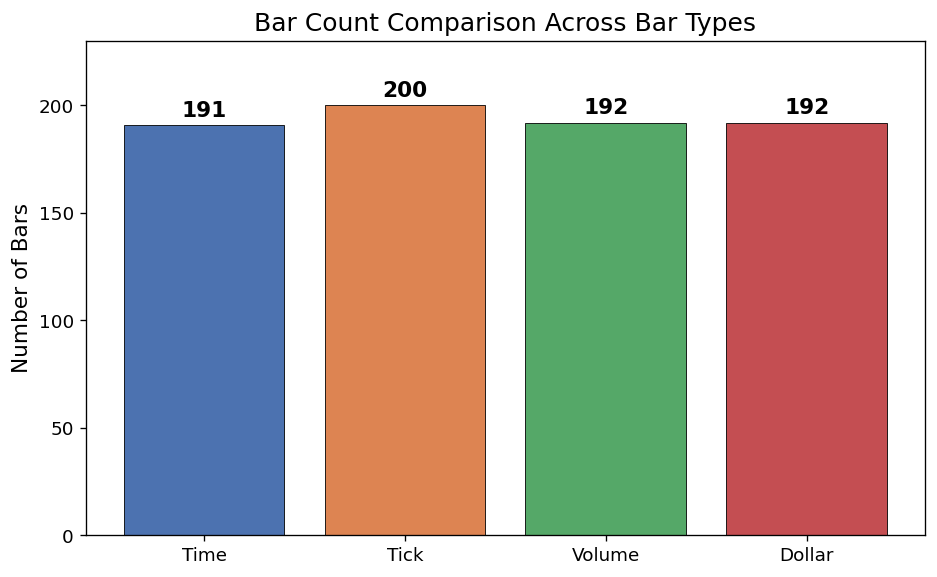

In [8]:
# Bar count comparison chart
bar_types = ['Time', 'Tick', 'Volume', 'Dollar']
bar_counts = [len(time_bars), len(tick_bars), len(vol_bars), len(dollar_bars)]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bar_types, bar_counts, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Number of Bars')
ax.set_title('Bar Count Comparison Across Bar Types')
for bar, count in zip(bars, bar_counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(bar_counts) * 1.15)
plt.tight_layout()
plt.show()

## Price Series with Bar Boundaries

This visualization shows the raw price series and marks where each bar type places
its bar boundaries. Notice how information-driven bars cluster during high-activity
periods.

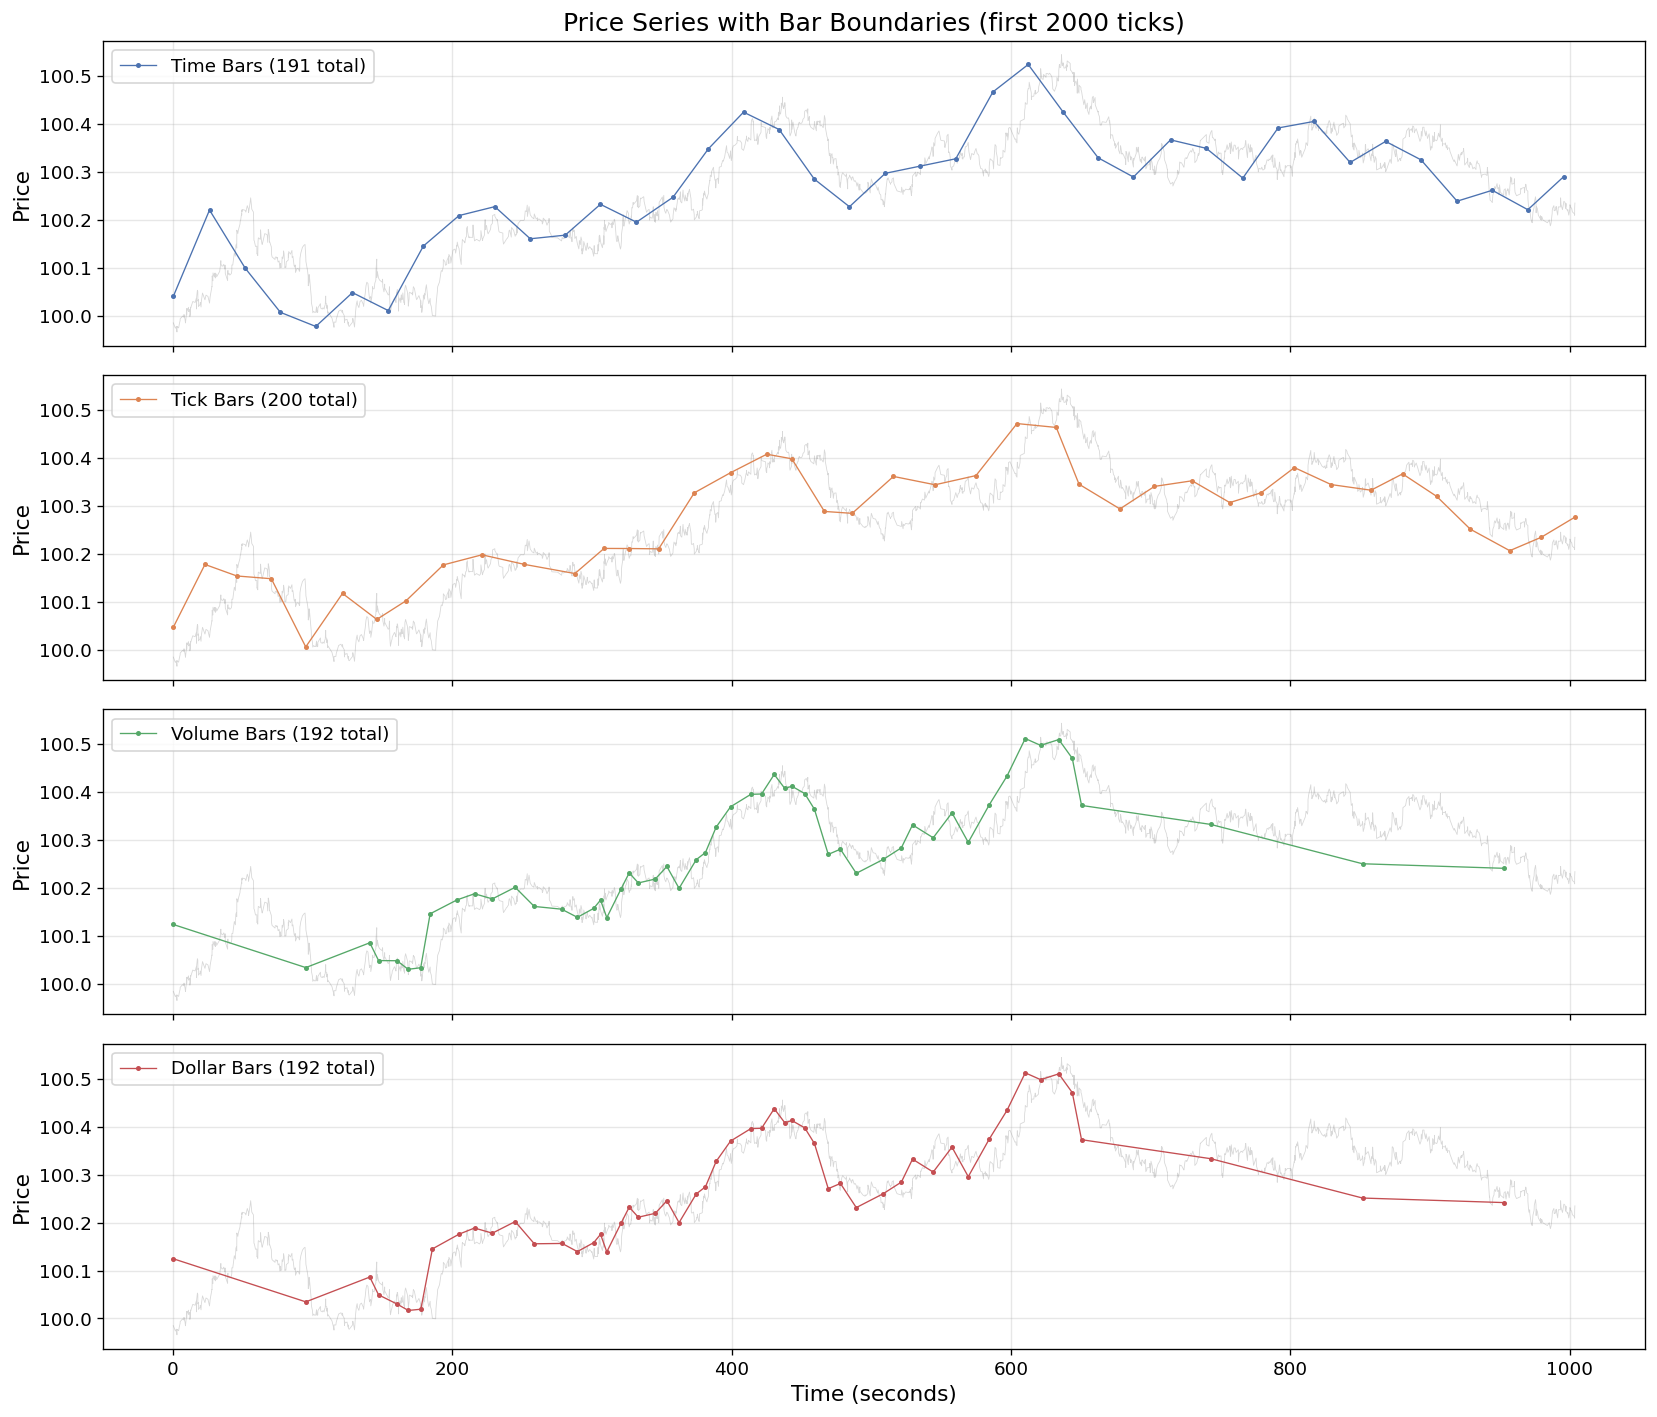

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

bar_data = [
    ('Time Bars', time_bars, '#4C72B0'),
    ('Tick Bars', tick_bars, '#DD8452'),
    ('Volume Bars', vol_bars, '#55A868'),
    ('Dollar Bars', dollar_bars, '#C44E52'),
]

for ax, (name, bars_list, color) in zip(axes, bar_data):
    # Plot raw price as background
    ax.plot(timestamps[:2000], prices[:2000], color='gray', alpha=0.3, linewidth=0.5)
    # Plot bar close prices
    bar_times = [b.timestamp for b in bars_list if b.timestamp <= timestamps[2000]]
    bar_closes = [b.close for b in bars_list if b.timestamp <= timestamps[2000]]
    ax.plot(bar_times, bar_closes, 'o-', color=color, markersize=2, linewidth=0.8,
            label=f'{name} ({len(bars_list)} total)')
    ax.set_ylabel('Price')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
axes[0].set_title('Price Series with Bar Boundaries (first 2000 ticks)')
plt.tight_layout()
plt.show()

## CUSUM Filter

The CUSUM (Cumulative Sum) filter detects structural breaks in the return series.
It triggers an event when the cumulative deviation from the mean exceeds a threshold.
This is used to identify potential entry points for trading strategies.

In [10]:
# CUSUM filter applied to close prices (AFML Snippet 2.4)
# The filter accumulates price changes and triggers when the
# cumulative move exceeds the threshold in either direction.
threshold = np.std(np.diff(prices)) * 10.0  # 10x one-step volatility
events = pymlfinance.data.cusum_filter(prices, threshold)
print(f"--- CUSUM Filter ---")
print(f"  Threshold: {threshold:.4f} (10x price step std)")
print(f"  Events detected: {len(events)}")
if len(events) >= 3:
    print(f"  First 3 event indices: {events[:3]}")

--- CUSUM Filter ---
  Threshold: 0.1000 (10x price step std)
  Events detected: 160
  First 3 event indices: [57, 99, 126]


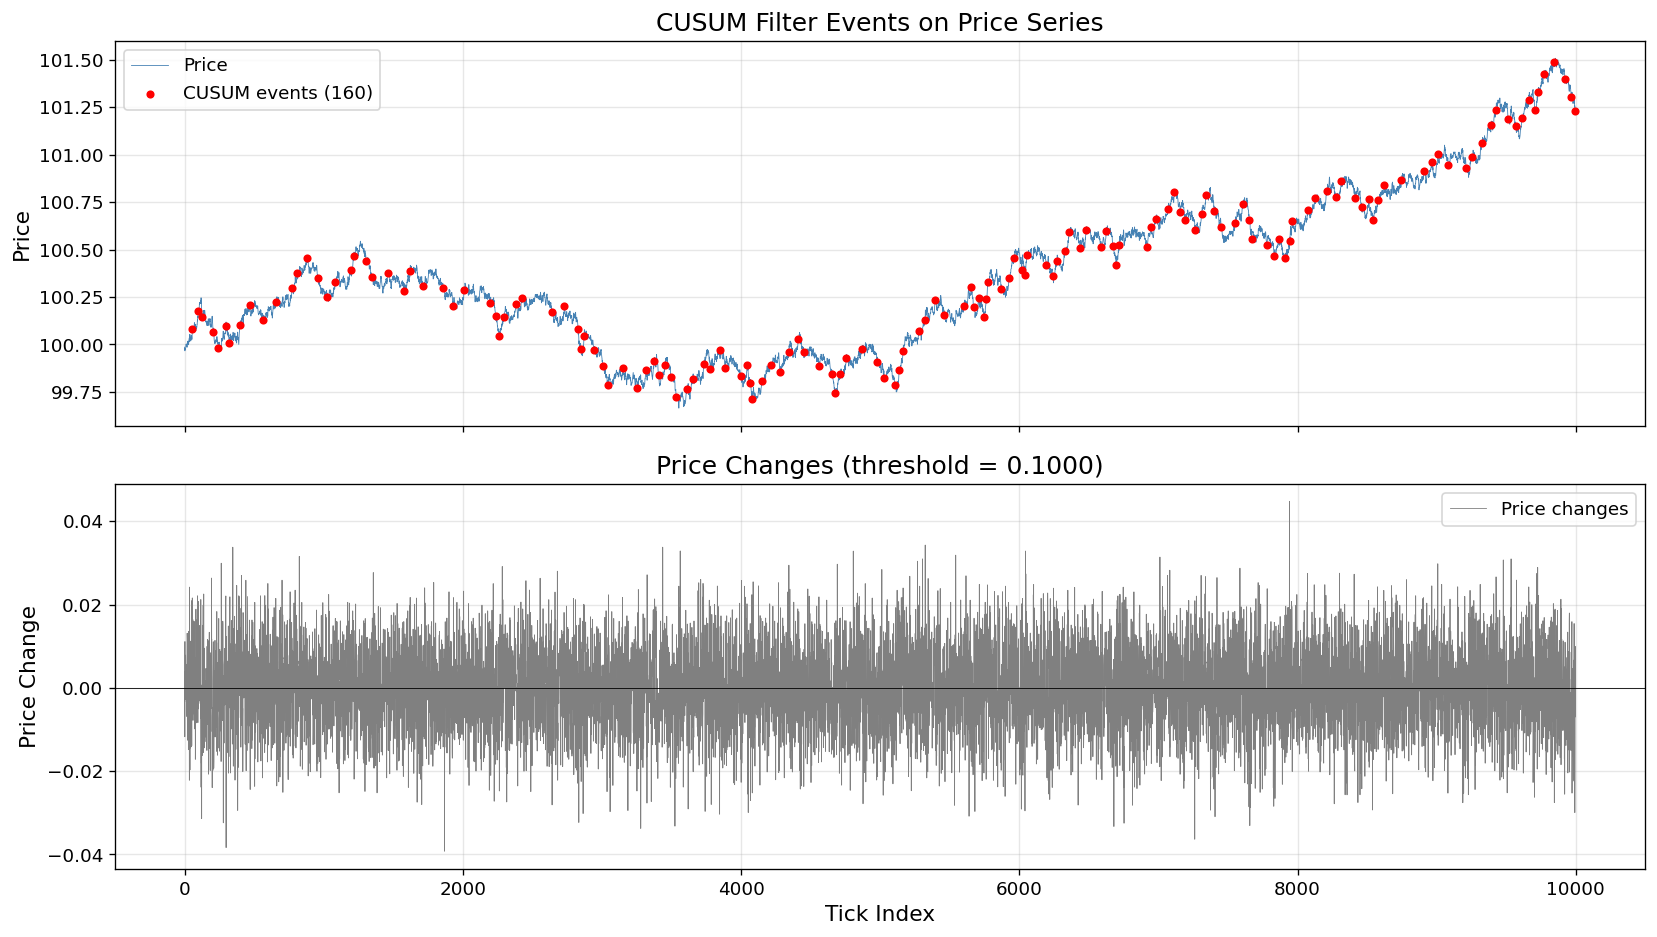

In [11]:
# Plot CUSUM events on the price series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(prices, color='steelblue', linewidth=0.5, label='Price')
if events:
    ax1.scatter(events, prices[events], color='red', s=15, zorder=5,
                label=f'CUSUM events ({len(events)})')
ax1.set_ylabel('Price')
ax1.set_title('CUSUM Filter Events on Price Series')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Show cumulative price changes to illustrate CUSUM accumulation
price_diffs = np.diff(prices)
ax2.plot(price_diffs, color='gray', linewidth=0.5, label='Price changes')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_xlabel('Tick Index')
ax2.set_ylabel('Price Change')
ax2.set_title(f'Price Changes (threshold = {threshold:.4f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exercises

1. **Tick bar size sensitivity**: Try different tick bar sizes (10, 50, 200) and compare the volatility per bar. Smaller bars should capture finer-grained moves.

2. **Volume clustering**: Increase volume clustering (change the `0.5` threshold in `np.sin(...) > 0.5` to `0.0`) and observe how volume bars adapt by producing more bars during high-activity regimes.

3. **Return distributions**: Compare bar return distributions across bar types. Information-driven bars should show more Gaussian-like returns.